# MiniParT — Full Notebook

This notebook assembles the exact original code cells from each lesson, in order. See the [lessons/](lessons/) folder and [README.md](README.md) for the full explanations.

## Lesson 1 — What Is a Jet?

See [lessons/01_what_is_a_jet.md](lessons/01_what_is_a_jet.md).

In [1]:
import uproot
import awkward as ak
import vector
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

vector.register_awkward()

# We avoid DeepJet/DeepCSV variables as requested.
# Using kinematics + energy fractions + pileup/multiplicity info.
FEATURE_NAMES = [
    'Jet_pt', 'Jet_eta', 'Jet_phi', 'Jet_mass',
    'Jet_chHEF', 'Jet_neHEF', 'Jet_chEmEF', 'Jet_neEmEF',
    'Jet_nConstituents', 'Jet_puId'
]

# Labels: 0 = Hbb, 1 = Hcc, 2 = QCD


## Lesson 2 — Finding the Truth Labels

See [lessons/02_finding_the_truth_labels.md](lessons/02_finding_the_truth_labels.md).

In [2]:
def delta_phi(phi1, phi2):
    dphi = phi1 - phi2
    return (dphi + np.pi) % (2*np.pi) - np.pi

def extract_features(filepath, label, is_signal=True, max_events=None):
    tree = uproot.open(filepath)["Events"]

    # Load required branches
    branches = FEATURE_NAMES.copy()
    if is_signal:
        branches += [
            "GenPart_pdgId", "GenPart_pt", "GenPart_eta",
            "GenPart_phi", "GenPart_mass", "GenPart_genPartIdxMother"
        ]

    events = tree.arrays(branches, entry_stop=max_events)

    if is_signal:
        # Determine target quark based on label (0: b-quark=5, 1: c-quark=4)
        target_pdg = 5 if label == 0 else 4

        mother_idx = events.GenPart_genPartIdxMother
        valid = mother_idx >= 0
        mother_pdg = ak.where(valid, events.GenPart_pdgId[mother_idx], -999)

        is_higgs_dau = (abs(events.GenPart_pdgId) == target_pdg) & (mother_pdg == 25)
        mask = ak.num(events.GenPart_pt[is_higgs_dau]) == 2
        events = events[mask]
        is_higgs_dau = is_higgs_dau[mask]

        # Build 4-vectors
        jets = ak.zip({
            "pt": events.Jet_pt, "eta": events.Jet_eta,
            "phi": events.Jet_phi, "mass": events.Jet_mass
        }, with_name="Momentum4D")

        dau = ak.zip({
            "pt": events.GenPart_pt[is_higgs_dau], "eta": events.GenPart_eta[is_higgs_dau],
            "phi": events.GenPart_phi[is_higgs_dau], "mass": events.GenPart_mass[is_higgs_dau]
        }, with_name="Momentum4D")

        d1, d2 = dau[:, 0], dau[:, 1]

        # Match using dR < 0.4
        dr1 = np.sqrt((jets.eta - d1.eta[:, None])**2 + delta_phi(jets.phi, d1.phi[:, None])**2)
        dr2 = np.sqrt((jets.eta - d2.eta[:, None])**2 + delta_phi(jets.phi, d2.phi[:, None])**2)
        matched = (dr1 < 0.4) | (dr2 < 0.4)

        # Extract features for matched jets
        matched_events = events[matched]

        # Keep exactly 2 matched jets
        mask_2jets = ak.num(matched_events.Jet_pt) == 2
        final_events = matched_events[mask_2jets]

    else:
        # For QCD, require at least 2 jets and take the top 2 leading jets
        mask_2jets = ak.num(events.Jet_pt) >= 2
        events = events[mask_2jets]
        # Slice to keep only the first 2 jets
        final_events = events[:, :2]

    # Stack features into a NumPy array of shape (N_events, 2_jets, N_features)
    feature_list = []
    for feat in FEATURE_NAMES:
        # Fill missing values with 0 (e.g., puId might have NaNs depending on pt)
        arr = ak.fill_none(final_events[feat], 0)
        feature_list.append(ak.to_numpy(arr))

    X = np.stack(feature_list, axis=-1)
    y = np.full(X.shape[0], label)

    print(f"Loaded label {label}: {X.shape[0]} events")
    return X, y


## Lesson 3 — Preparing the Data

See [lessons/03_preparing_the_data.md](lessons/03_preparing_the_data.md).

In [3]:
# Extract features (adjust max_events to None when ready for full training)
X_bb, y_bb = extract_features("datasets/ttHTobb.root", label=0, is_signal=True, max_events=50000)
X_cc, y_cc = extract_features("datasets/ttHTocc.root", label=1, is_signal=True, max_events=50000)
X_qcd, y_qcd = extract_features("datasets/qcd_bctoe.root", label=2, is_signal=False, max_events=50000)

# Combine datasets
X = np.concatenate([X_bb, X_cc, X_qcd], axis=0)
y = np.concatenate([y_bb, y_cc, y_qcd], axis=0)

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Normalize features (Transformers are sensitive to scale)
# We flatten to (N*2, Features) to fit the scaler, then reshape back
scaler = StandardScaler()
X_train_flat = X_train.reshape(-1, len(FEATURE_NAMES))
X_test_flat = X_test.reshape(-1, len(FEATURE_NAMES))

X_train_scaled = scaler.fit_transform(X_train_flat).reshape(-1, 2, len(FEATURE_NAMES))
X_test_scaled = scaler.transform(X_test_flat).reshape(-1, 2, len(FEATURE_NAMES))

# Convert to PyTorch tensors
train_data = TensorDataset(torch.tensor(X_train_scaled, dtype=torch.float32), torch.tensor(y_train, dtype=torch.long))
test_data = TensorDataset(torch.tensor(X_test_scaled, dtype=torch.float32), torch.tensor(y_test, dtype=torch.long))

train_loader = DataLoader(train_data, batch_size=256, shuffle=True)
test_loader = DataLoader(test_data, batch_size=256, shuffle=False)


Loaded label 0: 36023 events


Loaded label 1: 37296 events


Loaded label 2: 49999 events


## Lesson 4 — Building MiniParT

See [lessons/04_building_mini_part.md](lessons/04_building_mini_part.md).

In [4]:
class MiniParT(nn.Module):
    def __init__(self, input_dim, embed_dim=64, num_heads=4, hidden_dim=128, num_classes=3):
        super(MiniParT, self).__init__()

        # 1. Linear projection (Embedding)
        self.embedding = nn.Linear(input_dim, embed_dim)

        # 2. Transformer Encoder Layer (Self-Attention)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=hidden_dim,
            batch_first=True,
            dropout=0.1
        )
        # Using just 2 layers for a "mini" model to keep local training fast
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)

        # 3. Classification Head
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        # x shape: (Batch, Seq_Len=2, Features)

        # Project features
        x = self.embedding(x) # shape: (Batch, 2, embed_dim)

        # Apply self-attention
        x = self.transformer(x) # shape: (Batch, 2, embed_dim)

        # Mean pooling over the sequence (the 2 jets)
        x_pooled = x.mean(dim=1) # shape: (Batch, embed_dim)

        # Classify
        out = self.mlp(x_pooled) # shape: (Batch, num_classes)
        return out

model = MiniParT(input_dim=len(FEATURE_NAMES))
print(model)


MiniParT(
  (embedding): Linear(in_features=10, out_features=64, bias=True)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (mlp): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=128, out_features=3, bias=True)
  

## Lesson 5 — Training the Model

See [lessons/05_training_the_model.md](lessons/05_training_the_model.md).

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

epochs = 10

for epoch in range(epochs):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)

        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += batch_y.size(0)
        correct += predicted.eq(batch_y).sum().item()

    train_acc = 100. * correct / total
    print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss/len(train_loader):.4f} | Train Acc: {train_acc:.2f}%")


Epoch 1/10 | Loss: 0.7018 | Train Acc: 65.42%


Epoch 2/10 | Loss: 0.5902 | Train Acc: 70.47%


Epoch 3/10 | Loss: 0.5774 | Train Acc: 71.06%


Epoch 4/10 | Loss: 0.5743 | Train Acc: 71.20%


Epoch 5/10 | Loss: 0.5693 | Train Acc: 71.44%


Epoch 6/10 | Loss: 0.5665 | Train Acc: 71.65%


Epoch 7/10 | Loss: 0.5636 | Train Acc: 71.81%


Epoch 8/10 | Loss: 0.5617 | Train Acc: 71.91%


Epoch 9/10 | Loss: 0.5606 | Train Acc: 72.07%


Epoch 10/10 | Loss: 0.5574 | Train Acc: 72.10%


## Lesson 6 — Evaluating the Model

See [lessons/06_evaluating_the_model.md](lessons/06_evaluating_the_model.md).

In [6]:
model.eval()
correct = 0
total = 0

all_preds = []
all_labels = []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)

        outputs = model(batch_x)
        _, predicted = outputs.max(1)

        total += batch_y.size(0)
        correct += predicted.eq(batch_y).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(batch_y.cpu().numpy())

test_acc = 100. * correct / total
print(f"Final Test Accuracy: {test_acc:.2f}%")


Final Test Accuracy: 72.55%


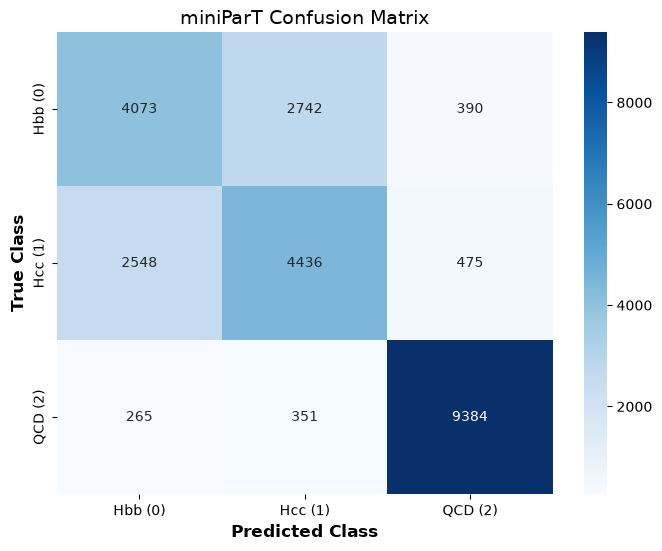

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import torch.nn.functional as F

model.eval()

all_labels = []
all_preds = []
all_probs = []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)

        outputs = model(batch_x)
        probs = F.softmax(outputs, dim=1)
        _, predicted = outputs.max(1)

        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(batch_y.cpu().numpy())

all_labels = np.array(all_labels)
all_preds = np.array(all_preds)
all_probs = np.array(all_probs)

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Hbb (0)', 'Hcc (1)', 'QCD (2)'],
            yticklabels=['Hbb (0)', 'Hcc (1)', 'QCD (2)'])

plt.xlabel('Predicted Class', fontsize=12, fontweight='bold')
plt.ylabel('True Class', fontsize=12, fontweight='bold')
plt.title('miniParT Confusion Matrix', fontsize=14)
plt.show()


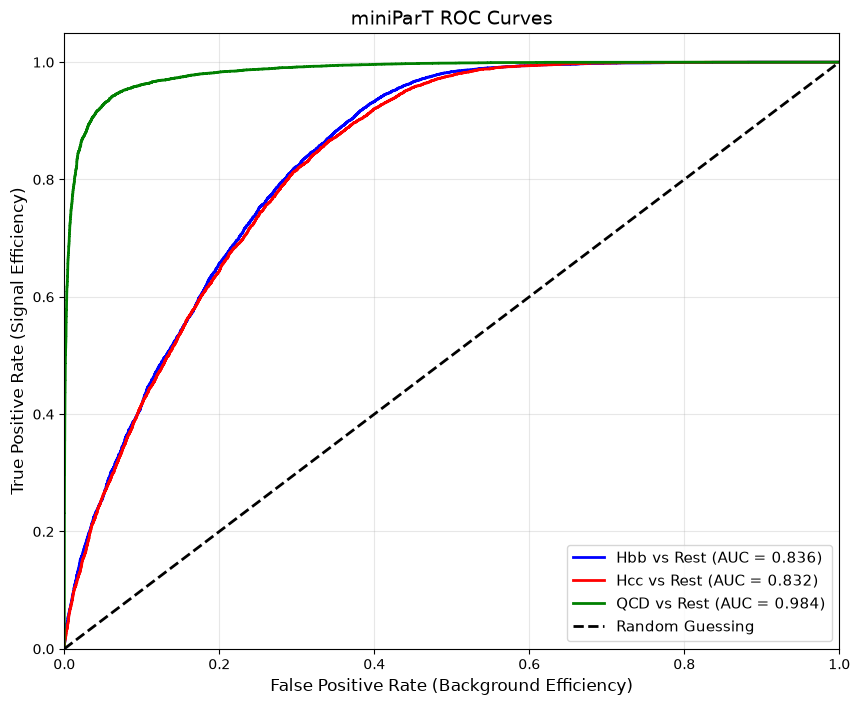

In [8]:
y_test_bin = label_binarize(all_labels, classes=[0, 1, 2])
n_classes = y_test_bin.shape[1]

plt.figure(figsize=(10, 8))
colors = ['blue', 'red', 'green']
class_names = ['Hbb', 'Hcc', 'QCD']

for i, color, name in zip(range(n_classes), colors, class_names):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'{name} vs Rest (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Guessing')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Background Efficiency)', fontsize=12)
plt.ylabel('True Positive Rate (Signal Efficiency)', fontsize=12)
plt.title('miniParT ROC Curves', fontsize=14)
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.show()


In [9]:
import torch.nn.functional as F
import pandas as pd

model.eval()

hbb_event, hcc_event, qcd_event = None, None, None

for i in range(len(y_test)):
    if y_test[i] == 0 and hbb_event is None:
        hbb_event = torch.tensor(X_test_scaled[i:i+1], dtype=torch.float32).to(device)
    elif y_test[i] == 1 and hcc_event is None:
        hcc_event = torch.tensor(X_test_scaled[i:i+1], dtype=torch.float32).to(device)
    elif y_test[i] == 2 and qcd_event is None:
        qcd_event = torch.tensor(X_test_scaled[i:i+1], dtype=torch.float32).to(device)

    if hbb_event is not None and hcc_event is not None and qcd_event is not None:
        break

def get_fingerprint(event_tensor):
    with torch.no_grad():
        emb = model.embedding(event_tensor)
        contextualized = model.transformer(emb)
        fingerprint = contextualized.mean(dim=1)
    return fingerprint

fp_hbb = get_fingerprint(hbb_event)
fp_hcc = get_fingerprint(hcc_event)
fp_qcd = get_fingerprint(qcd_event)

sim_hbb_hcc = F.cosine_similarity(fp_hbb, fp_hcc).item()
sim_hbb_qcd = F.cosine_similarity(fp_hbb, fp_qcd).item()
sim_hcc_qcd = F.cosine_similarity(fp_hcc, fp_qcd).item()

print("Cosine Similarity Matrix (1 = Identical, -1 = Opposite):\n")

data = {
    "Hbb": [1.0, sim_hbb_hcc, sim_hbb_qcd],
    "Hcc": [sim_hbb_hcc, 1.0, sim_hcc_qcd],
    "QCD": [sim_hbb_qcd, sim_hcc_qcd, 1.0]
}

df_sim = pd.DataFrame(data, index=["Hbb", "Hcc", "QCD"])
print(df_sim.round(3))


Cosine Similarity Matrix (1 = Identical, -1 = Opposite):

       Hbb    Hcc    QCD
Hbb  1.000 -0.058  0.392
Hcc -0.058  1.000  0.097
QCD  0.392  0.097  1.000
